In [ ]:
import pandas as pd
import zipfile
import os

# Αποσυμπίεση
zip_path = '/content/reduced_datasets.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/reduced_data/')

# Προβολή αρχείων στον φάκελο
os.listdir('/content/reduced_data/')

os.listdir('/content/reduced_data/content/preterm_dataset_versions/')

# Φόρτωση τελικού αρχείου
df = pd.read_excel('/content/reduced_data/content/preterm_dataset_versions/reduced_preterm_dataset_1.xlsx')

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,39.454795,31.428571,81.205926,0.805,1.20,4.9,2.01,1.00,168.0,0.97,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import numpy as np
from sklearn.preprocessing import StandardScaler

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
# n_estimators=100:αριθμός δέντρων στο δάσος (συνήθης επιλογή η συγκεκριμένη τιμή)
# class_weight='balanced': ενίσχυση του βάρους της κλάσης μειοψηφίας
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(rf, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
rf.fit(X_train_balanced, y_train_balanced)
y_pred = rf.predict(X_test) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = rf.predict_proba(X_test)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.9689
PRECISION: 0.9571
RECALL: 0.9823
F1: 0.9693
ROC_AUC: 0.9967
AVERAGE_PRECISION: 0.9967

Confusion Matrix:
 [[185   8]
 [  2  45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       193
           1       0.85      0.96      0.90        47

    accuracy                           0.96       240
   macro avg       0.92      0.96      0.94       240
weighted avg       0.96      0.96      0.96       240


ROC AUC Score: 0.9734869363906956

PR AUC Score: 0.9579114832316445


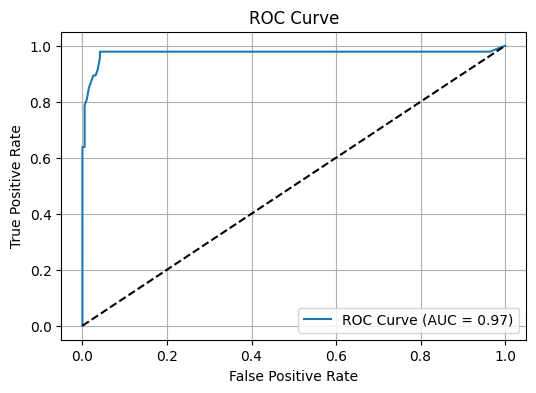

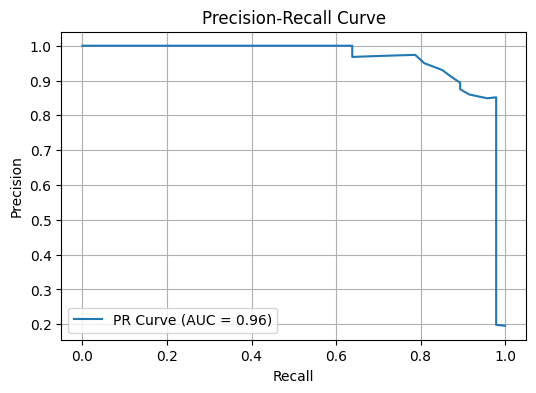

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

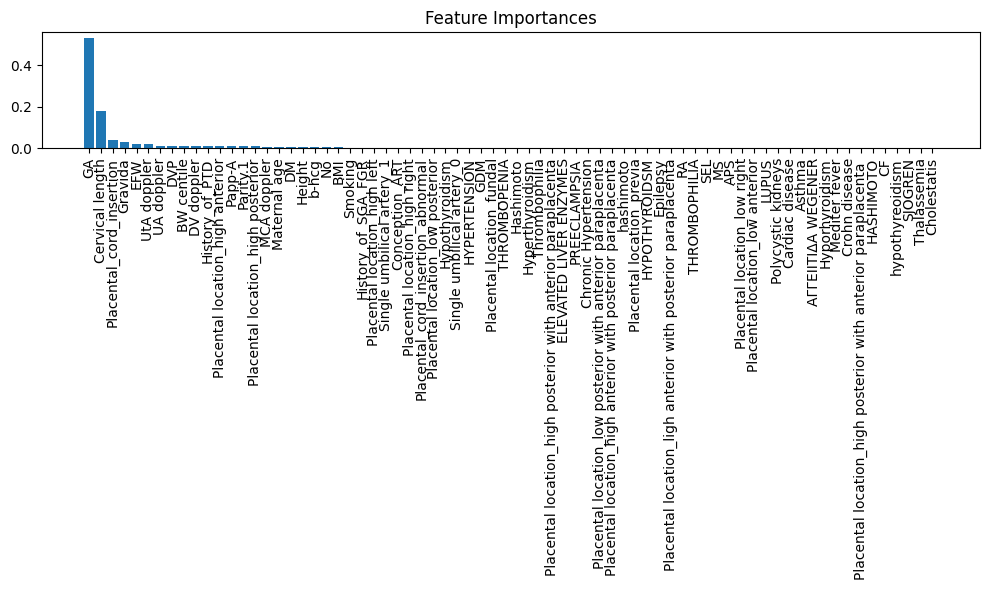

In [ ]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός μοντέλου Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']

cv_results = cross_validate(rf_reg, X_train, y_train, cv=cv, scoring=scoring)

# Εκπαίδευση στο πλήρες training set
rf_reg.fit(X_train, y_train)

# Προβλέψεις στο test set
y_pred = rf_reg.predict(X_test)

# Αξιολόγηση στο test set
print("\nEvaluation on Test Set:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


Evaluation on Test Set:
R² Score: 0.7602
MAE: 0.9250
MSE: 1.8988
RMSE: 1.3780


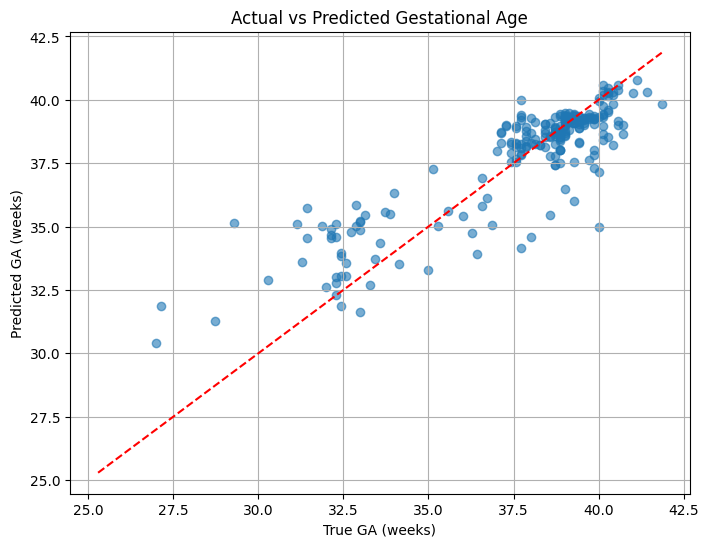

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("True GA (weeks)")
plt.ylabel("Predicted GA (weeks)")
plt.title("Actual vs Predicted Gestational Age")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Διαγώνια γραμμή
plt.grid(True)
plt.show()

In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [100, 200]: αριθμός δέντρων στο δάσος
# 'max_depth': [None, 10, 20]: μέγιστο βάθος κάθε δέντρου
# 'min_samples_split': [2, 5]: ελάχιστος αριθμός δειγμάτων για διαχωρισμό εσωτερικού κόμβου
# 'min_samples_leaf': [1, 2]: ελάχιστος αριθμός δειγμάτων σε φύλλο
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train, y_train)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Εκτύπωση μετρικών αξιολόγησης για το test set
print("\nEvaluation on Test Set (Optimized Random Forest Regressor):")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Evaluation on Test Set (Optimized Model):
R² Score: 0.7606
MAE: 0.9244
MSE: 1.8954
RMSE: 1.3767


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()

# Στρογγυλοποίηση της GA στο ακέραιο μέρος
df_reg['GA'] = np.floor(df_reg['GA']).astype(int)

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός μοντέλου Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['r2', 'neg_mean_absolute_error', 'neg_mean_squared_error']
cv_results = cross_validate(rf_reg, X_train, y_train, cv=cv, scoring=scoring)

# Εκπαίδευση στο πλήρες training set
rf_reg.fit(X_train, y_train)

# Προβλέψεις και στρογγυλοποίηση στο ακέραιο για αξιολόγηση του test set
y_pred = rf_reg.predict(X_test)
y_pred_rounded = np.round(y_pred).astype(int)

# Αξιολόγηση στο test set
print("\nEvaluation on Test Set (Rounded Predictions):")
print(f"R² Score: {r2_score(y_test, y_pred_rounded):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rounded):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rounded):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rounded)):.4f}")


Evaluation on Test Set (Rounded Predictions):
R² Score: 0.7431
MAE: 0.8583
MSE: 2.0250
RMSE: 1.4230


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_reg = df.dropna(subset=['GA']).copy()  # Αφαίρεση NaN από τη GA

# Στρογγυλοποίηση της GA στο ακέραιο μέρος
df_reg['GA'] = np.floor(df_reg['GA']).astype(int)

X = df_reg.drop(columns=['GA', 'Preterm_birth']) # Όλες οι μεταβλητές εκτός των GA και Preterm_birth (επηρεάζει την πρόβλεψη)
y = df_reg['GA'] # Η μεταβλητή στόχος (GA - εβδομάδα τοκετού)

# Διαχωρισμός σε Train(70%)/Test(30%) (δεν χρειάζεται stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [100, 200]: αριθμός δέντρων στο δάσος
# 'max_depth': [None, 10, 20]: μέγιστο βάθος κάθε δέντρου
# 'min_samples_split': [2, 5]: ελάχιστος αριθμός δειγμάτων για διαχωρισμό εσωτερικού κόμβου
# 'min_samples_leaf': [1, 2]: ελάχιστος αριθμός δειγμάτων σε φύλλο
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train, y_train)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)
y_pred_best_rounded = np.round(y_pred).astype(int)

# Εκτύπωση μετρικών αξιολόγησης για το test set
print("\nEvaluation on Test Set (Best GridSearch Model):")
print(f"R² Score: {r2_score(y_test, y_pred_best_rounded):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_rounded):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_best_rounded):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_rounded)):.4f}")

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Evaluation on Test Set (Best GridSearch Model):
R² Score: 0.7431
MAE: 0.8583
MSE: 2.0250
RMSE: 1.4230


In [ ]:
# Ανάλυση των τιμών της εβδομάδας τοκετού
print("Ελάχιστη εβδομάδα GA:", df['GA'].min())
print("Μέγιστη εβδομάδα GA:", df['GA'].max())
print("Περιγραφή:")
print(df['GA'].describe())

Ελάχιστη εβδομάδα GA: 25.28571428571428
Μέγιστη εβδομάδα GA: 41.85714285714285
Περιγραφή:
count    800.000000
mean      37.900179
std        2.755562
min       25.285714
25%       37.428571
50%       38.857143
75%       39.714286
max       41.857143
Name: GA, dtype: float64


In [ ]:
import numpy as np

# Συνάρτηση που μετατρέπει τον αριθμό εβδομάδας κύησης σε αντίστοιχο μήνα κύησης
def week_to_month(week):
    if 25 <= week <= 26:
        return '6ος μήνας'
    elif 27 <= week <= 30:
        return '7ος μήνας'
    elif 31 <= week <= 35:
        return '8ος μήνας'
    elif 36 <= week <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

df_grouped = df.copy() # Δημιουργία αντίγραφου του αρχικού DataFrame df, ώστε να μην επηρεαστεί το αρχικό
df_grouped['GA'] = pd.to_numeric(df_grouped['GA'], errors='coerce') # Μετατροπή της GA σε αριθμητική τιμή
df_grouped = df_grouped.dropna(subset=['GA']) # Αφαίρεση NaN από τη GA
df_grouped['GA_int'] = np.floor(df_grouped['GA']).astype(int)
# Εφαρμογή της συνάρτησης week_to_month σε κάθε GA και αποθήκευση του αποτελέσματος σε νέα στήλη 'birth_month'
df_grouped['month_birth'] = df_grouped['GA'].apply(week_to_month)
# Εκτύπωση των διαφορετικών τιμών της στήλης 'birth_month', ταξινομημένη κατά αύξουσα σειρά
print(df_grouped['month_birth'].value_counts().sort_index())

month_birth
10ος μήνας    135
6ος μήνας       2
7ος μήνας       7
8ος μήνας     118
9ος μήνας     538
Name: count, dtype: int64


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
# n_estimators=100:αριθμός δέντρων στο δάσος (συνήθης επιλογή η συγκεκριμένη τιμή)
# class_weight='balanced': ενίσχυση του βάρους της κλάσης μειοψηφίας
rf = RandomForestClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(rf, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
rf.fit(X_train_balanced, y_train_balanced)
y_pred = rf.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ACCURACY: 0.9407
PRECISION_MACRO: 0.9411
RECALL_MACRO: 0.9407
F1_MACRO: 0.9404

Confusion Matrix:
 [[ 28   2   7]
 [  0  35   4]
 [ 12  13 139]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.70      0.76      0.73        37
6ος-8ος μήνας       0.70      0.90      0.79        39
    9ος μήνας       0.93      0.85      0.89       164

     accuracy                           0.84       240
    macro avg       0.78      0.83      0.80       240
 weighted avg       0.85      0.84      0.84       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def month_birth(ga):
    if ga <= 35:
        return '6ος-8ος μήνας'
    elif ga <= 40:
        return '9ος μήνας'
    else:
        return '10ος μήνας'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης month_birth σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'month_birth'
df_clean['month_birth'] = df_clean['GA'].apply(month_birth)

X = df_clean.drop(columns=['GA', 'month_birth', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, month_birth, Preterm_birth
y = df_clean['month_birth'] # Η μεταβλητή στόχος (month_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [100, 200]: αριθμός δέντρων στο δάσος
# 'max_depth': [None, 10, 20]: μέγιστο βάθος κάθε δέντρου
# 'min_samples_split': [2, 5]: ελάχιστος αριθμός δειγμάτων για διαχωρισμό εσωτερικού κόμβου
# 'min_samples_leaf': [1, 2]: ελάχιστος αριθμός δειγμάτων σε φύλλο
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Confusion Matrix:
 [[ 27   2   8]
 [  0  35   4]
 [ 12  13 139]]

Classification Report:
                precision    recall  f1-score   support

   10ος μήνας       0.69      0.73      0.71        37
6ος-8ος μήνας       0.70      0.90      0.79        39
    9ος μήνας       0.92      0.85      0.88       164

     accuracy                           0.84       240
    macro avg       0.77      0.82      0.79       240
 weighted avg       0.85      0.84      0.84       240



In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
# n_estimators=100:αριθμός δέντρων στο δάσος (συνήθης επιλογή η συγκεκριμένη τιμή)
# class_weight='balanced': ενίσχυση του βάρους της κλάσης μειοψηφίας
rf = RandomForestClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(rf, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
rf.fit(X_train_balanced, y_train_balanced)
y_pred = rf.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

ACCURACY: 0.9497
PRECISION_MACRO: 0.9501
RECALL_MACRO: 0.9497
F1_MACRO: 0.9489

Confusion Matrix:
 [[ 2  0  0  1  0  0  0]
 [ 0 20  2  0  2  0  0]
 [ 0  6  2  1  2  0  0]
 [ 1  1  1  2  2  2  0]
 [ 0  3  0  0 55 16  0]
 [ 0  4  0  0 16 95  0]
 [ 0  0  0  0  0  4  0]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.67      0.67      0.67         3
       31-32       0.59      0.83      0.69        24
       33-34       0.40      0.18      0.25        11
       35-36       0.50      0.22      0.31         9
       37-38       0.71      0.74      0.73        74
       39-40       0.81      0.83      0.82       115
       41-42       0.00      0.00      0.00         4

    accuracy                           0.73       240
   macro avg       0.53      0.50      0.49       240
weighted avg       0.71      0.73      0.72       240



In [ ]:
df_grouped = df.copy()
df_grouped['GA'] = pd.to_numeric(df_grouped['GA'], errors='coerce')
df_grouped = df_grouped.dropna(subset=['GA'])

df_grouped['ga_bin'] = df_grouped['GA'].apply(ga_bin_2weeks)

# Έλεγχος της κατανομής
print(df_grouped['ga_bin'].value_counts().sort_index())

ga_bin
25-30     11
31-32     79
33-34     37
35-36     29
37-38    246
39-40    385
41-42     13
Name: count, dtype: int64


In [ ]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np

# Δημιουργία κατηγορικής μεταβλητής με βάση την GA
def ga_bin_2weeks(ga):
    # Στρογγυλοποίηση προς τα κάτω και μετατροπή σε integer
    week = int(np.floor(ga))

    if 25 <= week <= 30:
        return '25-30'
    elif 31 <= week <= 32:
        return '31-32'
    elif 33 <= week <= 34:
        return '33-34'
    elif 35 <= week <= 36:
        return '35-36'
    elif 37 <= week <= 38:
        return '37-38'
    elif 39 <= week <= 40:
        return '39-40'
    elif 41 <= week <= 42:
        return '41-42'
    else:
        return 'εκτός ορίων'

# Καθαρισμός δεδομένων
df['GA'] = pd.to_numeric(df['GA'], errors='coerce')
df_clean = df.dropna(subset=['GA']).copy()
# Εφαρμογή της συνάρτησης ga_bin σε κάθε GA και αποθήκευση του αποτελέσματος στη νέα στήλη 'ga_bin'
df_clean['ga_bin'] = df_clean['GA'].apply(ga_bin_2weeks)

X = df_clean.drop(columns=['GA', 'ga_bin', 'Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός των GA, ga_bin, Preterm_birth
y = df_clean['ga_bin'] # Η μεταβλητή στόχος (ga_bin)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# Ορισμός του πλέγματος παραμέτρων για τον Grid Search
# 'n_estimators': [100, 200]: αριθμός δέντρων στο δάσος
# 'max_depth': [None, 10, 20]: μέγιστο βάθος κάθε δέντρου
# 'min_samples_split': [2, 5]: ελάχιστος αριθμός δειγμάτων για διαχωρισμό εσωτερικού κόμβου
# 'min_samples_leaf': [1, 2]: ελάχιστος αριθμός δειγμάτων σε φύλλο
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

# Ορισμός του GridSearchCV για εύρεση των καλύτερων παραμέτρων
# cv=10: 10-fold cross-validation
# n_jobs=-1: χρήση όλων των διαθέσιμων πυρήνων CPU
# verbose=1: επίπεδο λεπτομέρειας στην έξοδο
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# Εκπαίδευση του Grid Search στο training set
grid_search.fit(X_train_balanced, y_train_balanced)

# Εκτύπωση των βέλτιστων παραμέτρων που βρέθηκαν
print("Best Parameters:", grid_search.best_params_)

# Βελτιστοποιημένο μοντέλο
best_model = grid_search.best_estimator_

# Πρόβλεψη στο test set με την χρήση του βέλτιστου μοντέλου
y_pred = best_model.predict(X_test)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Confusion Matrix:
 [[ 2  0  0  1  0  0  0]
 [ 0 19  3  0  1  1  0]
 [ 0  7  2  1  1  0  0]
 [ 1  2  1  1  3  1  0]
 [ 0  2  1  0 52 19  0]
 [ 0  4  0  0 13 98  0]
 [ 0  0  0  0  0  4  0]]

Classification Report:
               precision    recall  f1-score   support

       25-30       0.67      0.67      0.67         3
       31-32       0.56      0.79      0.66        24
       33-34       0.29      0.18      0.22        11
       35-36       0.33      0.11      0.17         9
       37-38       0.74      0.70      0.72        74
       39-40       0.80      0.85      0.82       115
       41-42       0.00      0.00      0.00         4

    accuracy                           0.72       240
   macro avg       0.48      0.47      0.47       240
weighted avg       0.70      0.72      0.71     

In [4]:
import pandas as pd
import zipfile
import os

# Διαδρομή αρχείου
file_path = '/content/Pre-term-labour-Data-ready-for-ml-pipeline_final.xlsx'

# Φόρτωση δεδομένων
df = pd.read_excel(file_path)

# Προβολή δεδομένων
df.head()

,Maternal age,GA,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,32.000000,24.285714,20.378457,1.010,0.98,5.1,2.03,0.90,166.0,1.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,33.000000,25.285714,16.129898,0.880,0.95,4.0,2.10,1.12,165.0,0.91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,36.435616,32.571429,74.037300,0.675,1.30,3.6,1.87,0.50,175.0,0.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,42.000000,28.714286,71.680853,1.350,1.00,1.4,1.87,0.90,160.0,1.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,33.000000,29.285714,22.836726,0.640,1.13,4.1,2.02,1.12,163.0,1.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
# Φόρτωση απαραίτητων βιβλιοθηκών
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import numpy as np
from sklearn.preprocessing import StandardScaler

# Καθαρισμός δεδομένων
df['Preterm_birth'] = pd.to_numeric(df['Preterm_birth'], errors='coerce')
df_clean = df.dropna(subset=['Preterm_birth']).copy() # Αφαίρεση των γραμμών με τιμή NaN
df_clean = df_clean.drop(columns=['GA']) # Αφαίρεση γιατί επηρεάζει σημαντικά την πρόβλεψη
df_clean['Preterm_birth'] = df_clean['Preterm_birth'].astype(int)

X = df_clean.drop(columns=['Preterm_birth']) # Όλες οι μεταβλητές του dataset εκτός της Preterm_birth
y = df_clean['Preterm_birth'] # Η μεταβλητή στόχος (Preterm_birth)

# Διαχωρισμός σε Train(70%)/Test(30%) (πριν την εξισορρόπηση)
# random_state=42: αναπαραγωγιμότητα του ίδιου αποτελέσματος
# stratify=y: απαλοιφή ανισορροπιών στα δύο sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Εξισορρόπηση μόνο στο training set
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

# 10-Fold Cross-Validation για internal validation
# n_estimators=100:αριθμός δέντρων στο δάσος (συνήθης επιλογή η συγκεκριμένη τιμή)
# class_weight='balanced': ενίσχυση του βάρους της κλάσης μειοψηφίας
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(rf, X_train_balanced, y_train_balanced, cv=cv, scoring=scoring)
# Εκτύπωση του μέσου όρου κάθε μετρικής από τα 10 folds
for metric in scoring:
    print(f"{metric.upper()}: {np.mean(cv_results['test_' + metric]):.4f}")

# Τελική εκπαίδευση στο balanced training set και αξιολόγηση στο test set
rf.fit(X_train_balanced, y_train_balanced)
y_pred = rf.predict(X_test) # Προβλέψεις ανά κατηγορία ('0' ή '1')
y_proba = rf.predict_proba(X_test)[:, 1] # Πιθανότητες για την κατηγορία '1' (πρόωρος τοκετός)

# Αποτελέσματα
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
print("\nPR AUC Score:", average_precision_score(y_test, y_proba))

ACCURACY: 0.9601
PRECISION: 0.9490
RECALL: 0.9733
F1: 0.9605
ROC_AUC: 0.9936
AVERAGE_PRECISION: 0.9936

Confusion Matrix:
 [[184   9]
 [  6  92]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       193
           1       0.91      0.94      0.92        98

    accuracy                           0.95       291
   macro avg       0.94      0.95      0.94       291
weighted avg       0.95      0.95      0.95       291


ROC AUC Score: 0.9905625462620281

PR AUC Score: 0.9804809410040858
